In [5]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Simplificar do dataset para facilitar o uso de filtros

In [6]:
file = "yellow_tripdata_2015-01.parquet"
silver_path = Path().cwd().parent / "data" / "silver" / file
df = pl.read_parquet(silver_path)
df.head(10)

vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code_id,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_minutes,hour_of_day,day_of_week,speed_mph
i64,datetime[μs],datetime[μs],i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,f64
2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,"""N""",-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05,18.05,19,4,5.285319
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.3,-74.001648,40.724243,1,"""N""",-73.994415,40.759109,1,14.5,0.5,0.5,2.0,0.0,0.3,17.8,19.833333,20,6,9.983193
1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.8,-73.963341,40.802788,1,"""N""",-73.95182,40.824413,2,9.5,0.5,0.5,0.0,0.0,0.3,10.8,10.05,20,6,10.746269
1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.5,-74.009087,40.713818,1,"""N""",-74.004326,40.719986,2,3.5,0.5,0.5,0.0,0.0,0.3,4.8,1.866667,20,6,16.071429
1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.0,-73.971176,40.762428,1,"""N""",-74.004181,40.742653,2,15.0,0.5,0.5,0.0,0.0,0.3,16.3,19.316667,20,6,9.318378
1,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.2,-73.983276,40.726009,1,"""N""",-73.99247,40.749634,2,14.0,0.5,0.5,0.0,0.0,0.3,15.3,24.866667,20,6,5.308311
1,2015-01-10 20:33:39,2015-01-10 20:42:20,3,0.8,-74.002663,40.734142,1,"""N""",-73.99501,40.726326,1,7.0,0.5,0.5,1.66,0.0,0.3,9.96,8.683333,20,6,5.527831
1,2015-01-10 20:33:40,2015-01-10 20:40:44,2,0.9,-73.985588,40.767948,1,"""N""",-73.985916,40.759365,1,6.5,0.5,0.5,1.55,0.0,0.3,9.35,7.066667,20,6,7.641509
1,2015-01-10 20:33:40,2015-01-10 20:41:39,1,0.9,-73.988617,40.723103,1,"""N""",-74.004395,40.728584,1,7.0,0.5,0.5,1.66,0.0,0.3,9.96,7.983333,20,6,6.764092


## Correlações direta: Distância x Preço


A correlação entre distância e preço é:
shape: (1, 1)
┌───────────────┐
│ trip_distance │
│ ---           │
│ f64           │
╞═══════════════╡
│ 0.920509      │
└───────────────┘


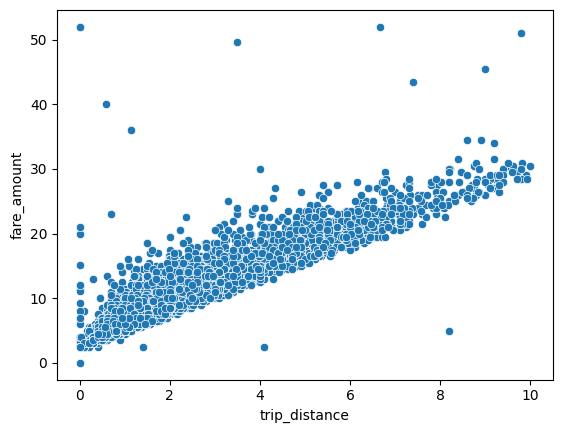

In [7]:
cr_distancia_preco = df.select(pl.corr("trip_distance", "fare_amount"))

print("A correlação entre distância e preço é:")
print(cr_distancia_preco)

sns.scatterplot(data=df.sample(10000), x="trip_distance", y="fare_amount")
plt.show()

## Correlações direta: Número de Passageiros x Preço



Média de preço de acordo com o número de passageiros:
shape: (4, 3)
┌─────────────────┬─────────────┬──────────────┐
│ passenger_count ┆ preco_medio ┆ qtd_corridas │
│ ---             ┆ ---         ┆ ---          │
│ i64             ┆ f64         ┆ u32          │
╞═════════════════╪═════════════╪══════════════╡
│ 1               ┆ 9.640192    ┆ 8098702      │
│ 2               ┆ 9.833752    ┆ 1616562      │
│ 3               ┆ 9.849736    ┆ 476790       │
│ 4               ┆ 9.897103    ┆ 228230       │
└─────────────────┴─────────────┴──────────────┘


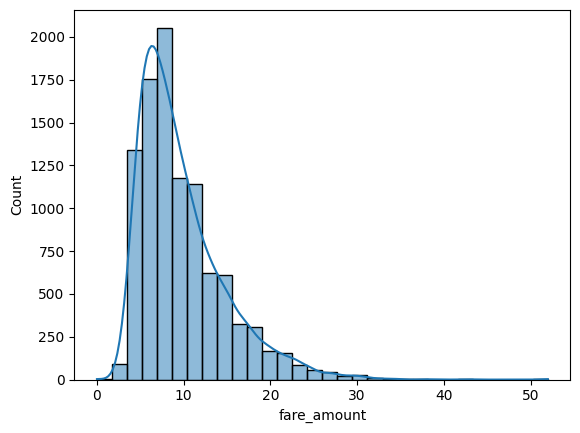

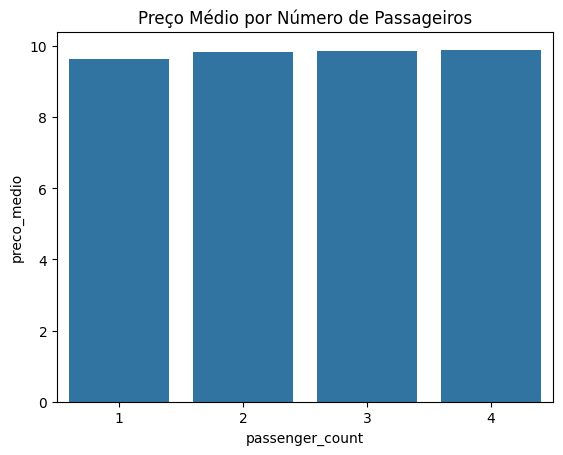

In [8]:
analise_passageiros = df.group_by("passenger_count").agg(
    pl.col("fare_amount").mean().alias("preco_medio"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("passenger_count")

print("\nMédia de preço de acordo com o número de passageiros:")
print(analise_passageiros)

sns.histplot(
    data=df.filter(pl.col("fare_amount").is_between(0, 60)).sample(10000).to_pandas(), 
    x="fare_amount", 
    kde=True, 
    bins=30
)
plt.show()

sns.barplot(
    data=analise_passageiros.to_pandas(), 
    x="passenger_count", 
    y="preco_medio"
)
plt.title("Preço Médio por Número de Passageiros")
plt.show()

## Correlação direta: Tempo x Preço

A correlação entre tempo e preço é: 0.1644


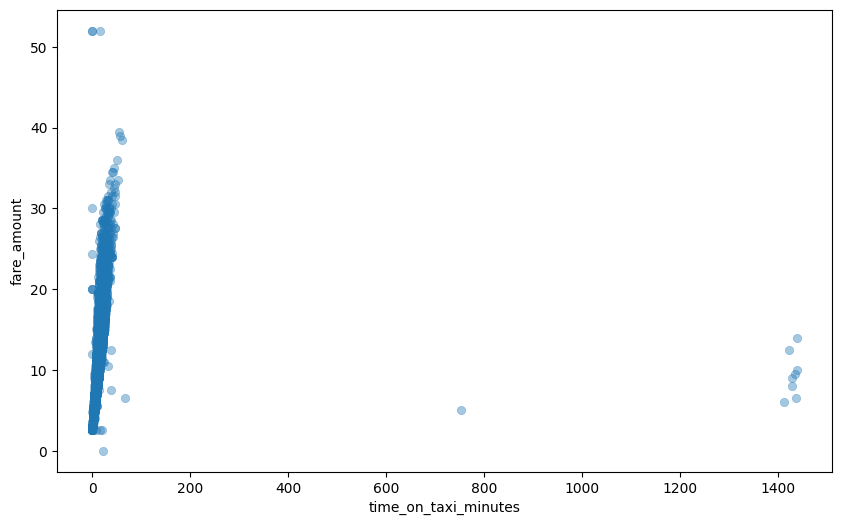

In [9]:
df_tempo_taxi = df.with_columns([
    (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
    .dt.total_minutes()
    .alias("time_on_taxi_minutes")
])

cr_tempo_preco = df_tempo_taxi.select(
    pl.corr("time_on_taxi_minutes", "fare_amount")
).item() # .item() extrai o valor numérico direto da tabela

print(f"A correlação entre tempo e preço é: {cr_tempo_preco:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_tempo_taxi.sample(10000).to_pandas(),
    x="time_on_taxi_minutes", 
    y="fare_amount",
    alpha=0.4,
    edgecolor=None
)
plt.show()

## Correlação Indireta: Forma de Pagamento X Preço

In [10]:
analise_pagamento = df.group_by("payment_type").agg(
    pl.col("fare_amount").mean().alias("preco_medio"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("payment_type", descending=False)

print("Média de preço por tipo de pagamento:")
print(analise_pagamento)

Média de preço por tipo de pagamento:
shape: (5, 3)
┌──────────────┬─────────────┬──────────────┐
│ payment_type ┆ preco_medio ┆ qtd_corridas │
│ ---          ┆ ---         ┆ ---          │
│ i64          ┆ f64         ┆ u32          │
╞══════════════╪═════════════╪══════════════╡
│ 1            ┆ 9.88679     ┆ 6318111      │
│ 2            ┆ 9.379059    ┆ 4060941      │
│ 3            ┆ 8.820372    ┆ 32639        │
│ 4            ┆ 9.71315     ┆ 8591         │
│ 5            ┆ 3.0         ┆ 2            │
└──────────────┴─────────────┴──────────────┘


## Correlação Indireta: Gorjeta x Pagamento Em dinheiro

In [11]:
analise_pagamento_dinheiro = df.group_by("payment_type").agg(
    pl.col("tip_amount").mean().alias("gorjeta_medio"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("payment_type", descending=False)

print("Gorjeta por pagamento em dinheiro:")
print(analise_pagamento_dinheiro)

Gorjeta por pagamento em dinheiro:
shape: (5, 3)
┌──────────────┬───────────────┬──────────────┐
│ payment_type ┆ gorjeta_medio ┆ qtd_corridas │
│ ---          ┆ ---           ┆ ---          │
│ i64          ┆ f64           ┆ u32          │
╞══════════════╪═══════════════╪══════════════╡
│ 1            ┆ 1.927128      ┆ 6318111      │
│ 2            ┆ 0.000065      ┆ 4060941      │
│ 3            ┆ 0.000996      ┆ 32639        │
│ 4            ┆ 0.001946      ┆ 8591         │
│ 5            ┆ 0.0           ┆ 2            │
└──────────────┴───────────────┴──────────────┘


## Correlação Indireta: Extra x relação a hora da corrida

In [12]:
df_hora = df.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("hora_do_dia")
])

analise_rush = df_hora.group_by("hora_do_dia").agg(
    pl.col("extra").mean().alias("media_taxa_extra"),
    pl.col("fare_amount").mean().alias("preco_medio_corrida"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("hora_do_dia")

print("Análise de taxas e preços por hora do dia:")
print(analise_rush)

Análise de taxas e preços por hora do dia:
shape: (24, 4)
┌─────────────┬──────────────────┬─────────────────────┬──────────────┐
│ hora_do_dia ┆ media_taxa_extra ┆ preco_medio_corrida ┆ qtd_corridas │
│ ---         ┆ ---              ┆ ---                 ┆ ---          │
│ i8          ┆ f64              ┆ f64                 ┆ u32          │
╞═════════════╪══════════════════╪═════════════════════╪══════════════╡
│ 0           ┆ 0.498496         ┆ 10.51122            ┆ 380566       │
│ 1           ┆ 0.49831          ┆ 10.673361           ┆ 290010       │
│ 2           ┆ 0.497874         ┆ 10.812048           ┆ 219381       │
│ 3           ┆ 0.497041         ┆ 10.96194            ┆ 159313       │
│ 4           ┆ 0.496016         ┆ 11.166558           ┆ 108772       │
│ …           ┆ …                ┆ …                   ┆ …            │
│ 19          ┆ 0.668657         ┆ 9.415257            ┆ 670810       │
│ 20          ┆ 0.502195         ┆ 9.542487            ┆ 604801       │
│ 21  

## Regressão linear: Distancia x Preço

In [13]:
X = df.select(["trip_distance"]).to_pandas() 
y = df.select("fare_amount").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # Guia do mochileiros da galaxia!

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Erro Médio (MAE): %{mean_absolute_error(y_test, y_pred):.2f}")

trip_distance = [[10]]

distancia_teste = [[10]]
previsao = lr.predict(distancia_teste)
print(f"\nPrevisão para 10 milhas: ${previsao[0][0]:.2f}")

R² Score: 0.8470
Erro Médio (MAE): %1.22

Previsão para 10 milhas: $33.34


/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Avaliação do modelo de regressão linear

Foi usado regressão linar simples com 75% dos dados usados para treinar o modelo e 25% foram usados para testar o modelo. Nesse caso usamos 

## Regressão linear: Número de Passageiros x Preço

In [14]:
X = df.select(["trip_distance", "passenger_count"]).to_pandas()
y = df.select("fare_amount").to_pandas()

# 2. Divisão de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treino do Modelo
modelo_passageiro = LinearRegression()
modelo_passageiro.fit(X_train, y_train)

# 4. O "Pulo do Gato": Interpretando os Coeficientes
coeficientes = dict(zip(X.columns, modelo_passageiro.coef_[0]))
print(f"Impacto da Distância: ${coeficientes['trip_distance']:.2f} por milha")
print(f"Impacto de cada Passageiro: ${coeficientes['passenger_count']:.2f} no valor final")

passageiros_preco = [[10, 3]]

previsao = modelo_passageiro.predict(passageiros_preco)

print(f"\nPrevisão para 10 milhas com 3 passageiros: ${previsao[0][0]:.2f}")

Impacto da Distância: $2.96 por milha
Impacto de cada Passageiro: $0.01 no valor final

Previsão para 10 milhas com 3 passageiros: $33.35


/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Regressão linear: Tempo x Preço

In [15]:
X = df_tempo_taxi.select("time_on_taxi_minutes").to_pandas()
y = df_tempo_taxi.select("fare_amount").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_tempo = LinearRegression()
modelo_tempo.fit(X_train, y_train)

y_pred = modelo_tempo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Avaliação do Modelo de Tempo ---") # Falta mexer para colocar a velocidade
print(f"R² (Poder de explicação): {r2:.4f}")
print(f"Erro Médio (MAE): ${mae:.2f}")

print(f"Valor por minuto: ${modelo_tempo.coef_[0][0]:.2f}")

tempo_preco = [[20]]

previsao = modelo_tempo.predict(tempo_preco)


print(f"\nPrevisão para 20 minutos no taxi: ${previsao[0][0]:.2f}")

--- Avaliação do Modelo de Tempo ---
R² (Poder de explicação): 0.0273
Erro Médio (MAE): $3.68
Valor por minuto: $0.02

Previsão para 20 minutos no taxi: $9.88


/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Regressão linear: Forma de Pagamento X Preco

In [16]:
df_pagamento = df.select(["payment_type", "fare_amount"])
df_dummies = df_pagamento.to_dummies("payment_type")

X = df_dummies.drop("fare_amount")
y = df_dummies.select("fare_amount")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_pagamento = LinearRegression()
modelo_pagamento.fit(X_train, y_train)

y_pred = modelo_pagamento.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Avaliação por Forma de Pagamento (Polars) ---")
print(f"R² (Poder de explicação): {r2:.4f}")
print(f"Erro Médio (MAE): ${mae:.2f}")

coeficientes = dict(zip(X.columns, modelo_pagamento.coef_[0]))
print("\nImpacto no preço por tipo de pagamento (em relação à base):")
for tipo, valor in coeficientes.items():
    print(f"- {tipo}: ${valor:.2f}")


fm_preco = [[0, 1, 0, 0, 0]]

previsao = modelo_pagamento.predict(fm_preco)


print(f"\nPrevisão para forma de pagamento 2 com 20 dolares: ${previsao[0][0]:.2f}")

--- Avaliação por Forma de Pagamento (Polars) ---
R² (Poder de explicação): 0.0026
Erro Médio (MAE): $3.76

Impacto no preço por tipo de pagamento (em relação à base):
- payment_type_1: $1.14
- payment_type_2: $0.64
- payment_type_3: $0.03
- payment_type_4: $0.92
- payment_type_5: $-2.74

Previsão para forma de pagamento 2 com 20 dolares: $9.38


/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Regressão linear: Gorjeta x Pagamento Em dinheiro

In [17]:
# 1. Preparação: Dummies para pagamento e seleção da Gorjeta
df_gorjeta = df.select(["payment_type", "tip_amount"])
df_dummies_gorjeta = df_gorjeta.to_dummies("payment_type")

# 2. Variáveis X (Pagamentos) e y (Gorjeta)
X = df_dummies_gorjeta.drop("tip_amount")
y = df_dummies_gorjeta.select("tip_amount")

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Modelo
modelo_gorjeta = LinearRegression()
modelo_gorjeta.fit(X_train, y_train)

# 5. Avaliação
y_pred = modelo_gorjeta.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² da Gorjeta: {r2:.4f}")

coefs = dict(zip(X.columns, modelo_gorjeta.coef_[0]))
for tipo, valor in coefs.items():
    print(f"Impacto no registro de gorjeta ({tipo}): ${valor:.2f}")

tipos_para_testar = [[0,1,0,0,0]]

previsao = modelo_gorjeta.predict(tipos_para_testar)


print(f"\nPrevisão para forma de pagamento 2 com 20 dolares: ${previsao[0][0]:.2f}")

R² da Gorjeta: 0.5946
Impacto no registro de gorjeta (payment_type_1): $1.54
Impacto no registro de gorjeta (payment_type_2): $-0.39
Impacto no registro de gorjeta (payment_type_3): $-0.38
Impacto no registro de gorjeta (payment_type_4): $-0.38
Impacto no registro de gorjeta (payment_type_5): $-0.39

Previsão para forma de pagamento 2 com 20 dolares: $0.00


/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Regressão linear: Hora x Taxa extra

In [18]:
X = df_hora.select("hora_do_dia")
y = df_hora.select("extra")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rush = LinearRegression()
modelo_rush.fit(X_train, y_train)

y_pred = modelo_rush.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Avaliação de Taxas Extras (Rush Hour) ---")
print(f"R²: {r2:.4f}")
print(f"Erro Médio (MAE): ${mae:.2f}")
print(f"Coeficiente (Impacto por hora): {modelo_rush.coef_[0][0]:.4f}")

hora_taxa = [[12]]

previsao = modelo_rush.predict(hora_taxa)

print(f"\nPrevisão de taxa extra para às {hora_taxa[0][0]}h: ${previsao[0][0]:.2f}")

--- Avaliação de Taxas Extras (Rush Hour) ---
R²: 0.0976
Erro Médio (MAE): $0.30
Coeficiente (Impacto por hora): 0.0177

Previsão de taxa extra para às 12h: $0.29


/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
